In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# EDA

In [3]:
db = pd.read_csv('diabetes.csv')
db.head()

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,1,89,66,23,94,28.1,0.167,21,neg
1,0,137,40,35,168,43.1,2.288,33,pos
2,3,78,50,32,88,31.0,0.248,26,pos
3,2,197,70,45,543,30.5,0.158,53,pos
4,1,189,60,23,846,30.1,0.398,59,pos


The objective of the data set is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the data set. 
There are 8 independent columns(features) which will help us predict diabetes(dependent) either as postive or negative

In [4]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  392 non-null    int64  
 1   glucose   392 non-null    int64  
 2   pressure  392 non-null    int64  
 3   triceps   392 non-null    int64  
 4   insulin   392 non-null    int64  
 5   mass      392 non-null    float64
 6   pedigree  392 non-null    float64
 7   age       392 non-null    int64  
 8   diabetes  392 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 27.7+ KB


Data has no NaN values, and we need to change the dtype of diabetes column

In [6]:
db['diabetes'] = db['diabetes'].map({"neg":0,"pos":1})

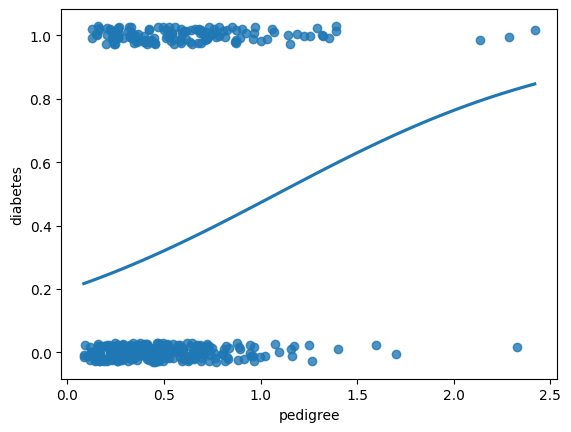

In [7]:
sns.regplot(x='pedigree',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.show()

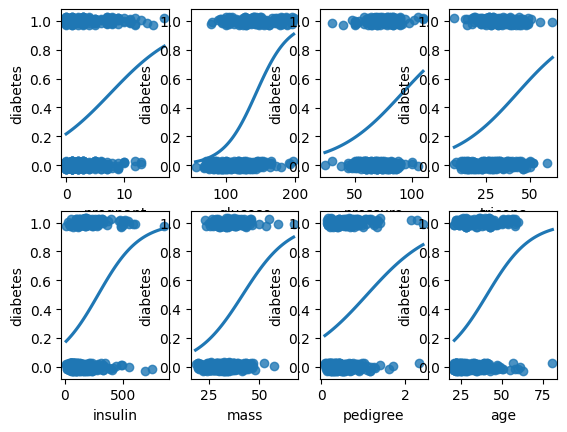

In [8]:
plt.subplot(2,4,1)
sns.regplot(x='pregnant',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,2)
sns.regplot(x='glucose',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,3)
sns.regplot(x='pressure',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,4)
sns.regplot(x='triceps',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,5)
sns.regplot(x='insulin',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,6)
sns.regplot(x='mass',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,7)
sns.regplot(x='pedigree',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)
plt.subplot(2,4,8)
sns.regplot(x='age',y='diabetes',y_jitter=0.03,data=db,logistic=True,ci=None)

plt.show()

# Model Fitting (Binary Logistic Regression)

In [10]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import logit

train_data , test_data = train_test_split(db,test_size=0.2,random_state=42)

formula = (
    'diabetes ~ pregnant + glucose + pressure + triceps + insulin + mass + pedigree + age'
)
model = logit(formula=formula, data=train_data).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.426450
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               diabetes   No. Observations:                  313
Model:                          Logit   Df Residuals:                      304
Method:                           MLE   Df Model:                            8
Date:                Sat, 13 Dec 2025   Pseudo R-squ.:                  0.3269
Time:                        18:47:50   Log-Likelihood:                -133.48
converged:                       True   LL-Null:                       -198.29
Covariance Type:            nonrobust   LLR p-value:                 3.382e-24
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.3495      1.390     -7.444      0.000     -13.075      -7.624
pregnant       0.1181      0.063      1.888      0.059      -0.005       0.241
glucose        0.0380      0.006      5.937      0.000       0.025       0.051
pressure       0.0099      0.014      0.701      0.483      -0.018       0.037
triceps        0.0211      0.019      1.100      0.271      -0.017       0.059
insulin        0.0010      0.001      0.666      0.505      -0.002       0.004
mass           0.0472      0.032      1.476      0.140      -0.015       0.110
pedigree       1.2316      0.484      2.543      0.011       0.282       2.181
age            0.0188      0.020      0.950      0.342      -0.020       0.058
==============================================================================
"""

INTERPRETATION:  
>All positive coeff increases the prob of diabetes   
>we may use ODDS to better understand the dependence on the features


In [11]:
np.exp(model.params)

Intercept    0.000032
pregnant     1.125365
glucose      1.038708
pressure     1.009922
triceps      1.021353
insulin      1.000981
mass         1.048328
pedigree     3.426683
age          1.019004
dtype: float64

To be able to better interpret the effect of different features we may use Average Marginal Effects

In [12]:
AME = model.get_margeff()
AME.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               diabetes
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
pregnant       0.0161      0.008      1.921      0.055      -0.000       0.032
glucose        0.0052      0.001      7.577      0.000       0.004       0.007
pressure       0.0013      0.002      0.703      0.482      -0.002       0.005
triceps        0.0029      0.003      1.105      0.269      -0.002       0.008
insulin        0.0001      0.000      0.668      0.504      -0.000       0.001
mass           0.0064      0.004      1.494      0.135      -0.002       0.015
pedigree       0.1677      0.064      2.626      0.009       0.043       0.293
age            0.0026      0.003      0.956      0.339      -0.003       0.008
==============================================================================
"""

This implies that unit increase in pedigree , increases the probability of diabetes by 16.77%

# Evaluation on Test Data


In [13]:
from sklearn.metrics import classification_report, accuracy_score

# gives the prob of each data 
prediction = model.predict(exog=test_data)
# setting cutoff probability to 0.5
cutoff = 0.5
# converting prob to class labels
y_prediction = np.where(prediction > cutoff, 1, 0)
y_actual = test_data["diabetes"]

#confusion matrix
conf_matrix = pd.crosstab(
    y_actual,
    y_prediction,
    rownames=["Actual"],
    colnames=["Predicted"],
    margins=True
)
conf_matrix


Predicted,0,1,All
Actual,,,
0,44,8,52
1,11,16,27
All,55,24,79


In [15]:
# accuracy score
accuracy_score(y_actual, y_prediction)

0.759493670886076

Here accuracy is not a good measure when a class imbalance exists in the data set(majority of data is of diabetic negative patients)

In [18]:
print(classification_report(y_actual, y_prediction))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        52
           1       0.67      0.59      0.63        27

    accuracy                           0.76        79
   macro avg       0.73      0.72      0.72        79
weighted avg       0.75      0.76      0.76        79



As we can see we had imbalanced data that is why the precision and recall of diabatic patient is low

macro avg of F1 score is 0.72 , hence the model has 72% classification strength